This notebook is [Ruaf Momin's Kaggle notebook](https://www.kaggle.com/code/raufmomin/vision-transformer-vit-fine-tuning)

# Overview

This notebook implements Vision Transformer (ViT) model by Alexey Dosovitskiy et al for image classification, and demonstrates it on the Cassava Leaf Disease Classification dataset.

For from scratch implementation of ViT check out this notebook: <br>
https://www.kaggle.com/raufmomin/vision-transformer-vit-from-scratch

Research Paper: https://arxiv.org/pdf/2010.11929.pdf <br>
Github (Official) Link: https://github.com/google-research/vision_transformer <br>
Github (Keras) Link: https://github.com/faustomorales/vit-keras

#### Highlights of this notebook:
1. Pre-trained Vision Transformer (vit_b32) on imagenet21k dataset
2. Label Smoothing of 0.3
3. Custom data augmentation for ImageDataGenerator
4. RectifiedAdam Optimizer


# Model Architecture

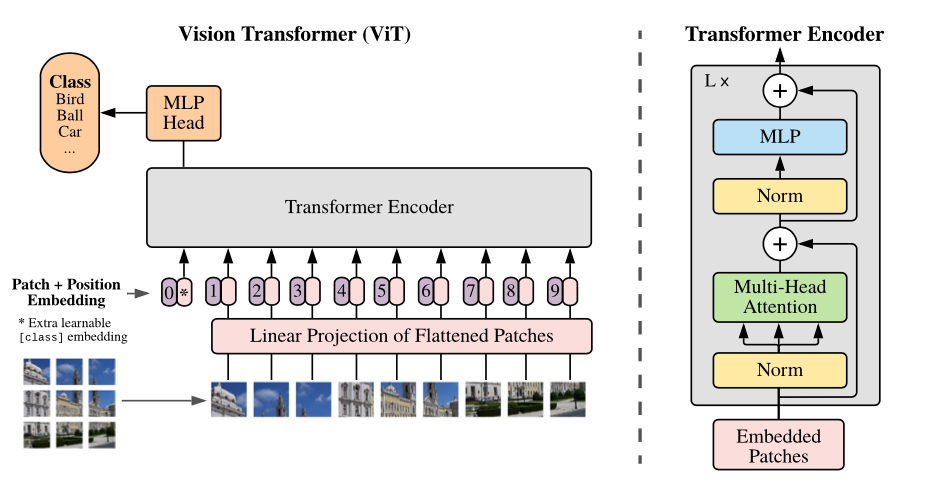

# Available models
There are models pre-trained on imagenet21k for the following architectures:
ViT-B/16, ViT-B/32, ViT-L/16, ViT-L/32 and ViT-H/14. 
There are also the same models pre-trained on imagenet21k and fine-tuned on imagenet2012.

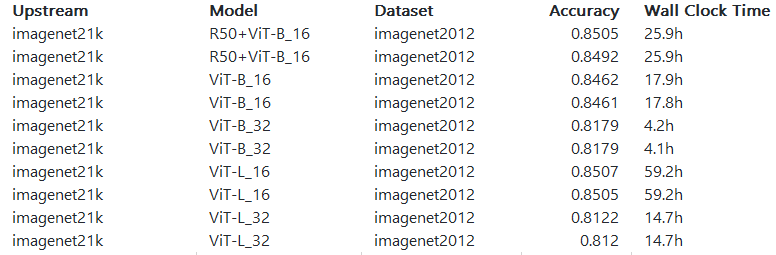

# Libraries and Configurations

In [36]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import pandas as pd
import numpy as np
import keras
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import glob
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
from PIL import Image

# keras_hub provides the pre-trained ViT backbone
try:
    import keras_hub
    _HAS_KERAS_HUB = True
except ImportError:
    _HAS_KERAS_HUB = False
    print("WARNING: keras_hub not installed. A custom ViT (no pre-trained weights) "
          "will be used as fallback.\n"
          "Install with: pip install keras-hub")

warnings.filterwarnings('ignore')
print(f"Keras version   : {keras.__version__}")
print(f"PyTorch version : {torch.__version__}")
print(f"Keras backend   : {keras.backend.backend()}")

Install with: pip install keras-hub
Keras version   : 3.8.0
PyTorch version : 2.6.0+cu124
Keras backend   : torch


In [37]:
IMAGE_SIZE = 224
BATCH_SIZE = 64
EPOCHS     = 7
NUM_CLASSES = 5

TRAIN_PATH = '/blue/bsc4892/share/cassava-leaf-disease-classification/train_images'
TEST_PATH  = '/blue/bsc4892/share/cassava-leaf-disease-classification/test_images'

DF_TRAIN    = pd.read_csv('/blue/bsc4892/share/cassava-leaf-disease-classification/train.csv', dtype='str')
TEST_IMAGES = glob.glob(TEST_PATH + '/*.jpg')
DF_TEST     = pd.DataFrame(TEST_IMAGES, columns=['image_path'])

classes = {
    0: "Cassava Bacterial Blight (CBB)",
    1: "Cassava Brown Streak Disease (CBSD)",
    2: "Cassava Green Mottle (CGM)",
    3: "Cassava Mosaic Disease (CMD)",
    4: "Healthy",
}

# Data Augmentations

In [38]:
# ── Training augmentations ──────────────────────────────────────────────────
# RandomApply replicates the probability-gated transforms from the original.
train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation(degrees=(90, 90))],   p=0.25),  # rotate 90°
    T.RandomApply([T.RandomRotation(degrees=(180, 180))], p=0.25),  # rotate 180°
    T.RandomApply([T.RandomRotation(degrees=(270, 270))], p=0.25),  # rotate 270°
    T.RandomApply([T.ColorJitter(saturation=(0.7, 1.3))], p=0.6),   # p_pixel_1 >= .4
    T.RandomApply([T.ColorJitter(contrast=(0.8, 1.2))],   p=0.6),   # p_pixel_2 >= .4
    T.RandomApply([T.ColorJitter(brightness=0.1)],        p=0.6),   # p_pixel_3 >= .4
])

# ── Validation / test: resize only ─────────────────────────────────────────
val_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

# Data Generator

In [39]:
def _samplewise_normalize(img: np.ndarray) -> np.ndarray:
    """Replicate ImageDataGenerator(rescale=1/255, samplewise_center=True,
    samplewise_std_normalization=True)."""
    img = img.astype(np.float32) / 255.0
    img -= img.mean()
    std = img.std()
    if std > 1e-7:
        img /= std
    return img


class CassavaDataset(Dataset):
    """Cassava leaf-disease dataset.  Returns images in (H, W, C) float32 format."""

    def __init__(self, df, img_dir, transform=None, is_test=False, num_classes=NUM_CLASSES):
        self.df          = df.reset_index(drop=True)
        self.img_dir     = img_dir
        self.transform   = transform
        self.is_test     = is_test
        self.num_classes = num_classes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.is_test:
            img_path = self.df.iloc[idx]['image_path']
        else:
            img_name = self.df.iloc[idx]['image_id']
            img_path = os.path.join(self.img_dir, img_name)

        pil_img = Image.open(img_path).convert('RGB')

        if self.transform:
            pil_img = self.transform(pil_img)

        # Convert to NumPy (H, W, C) — Keras-native channel layout
        img_np = _samplewise_normalize(np.array(pil_img, dtype=np.uint8))

        if self.is_test:
            return img_np

        label = int(self.df.iloc[idx]['label'])
        # One-hot encode to match CategoricalCrossentropy
        one_hot = np.zeros(self.num_classes, dtype=np.float32)
        one_hot[label] = 1.0
        return img_np, one_hot

In [40]:
from sklearn.model_selection import train_test_split

demo_fraction = 0.3  # keep 20% of the training dataframe

DF_TRAIN_DEMO, _ = train_test_split(
    DF_TRAIN,
    train_size=demo_fraction,
    random_state=1,
    stratify=DF_TRAIN["label"],
)

# 80 / 20 split inside the demo subset
train_df, val_df = train_test_split(
    DF_TRAIN_DEMO,
    test_size=0.2,
    random_state=1,
    stratify=DF_TRAIN_DEMO["label"],
)

train_dataset = CassavaDataset(train_df, TRAIN_PATH, transform=train_transform)
val_dataset   = CassavaDataset(val_df,   TRAIN_PATH, transform=val_transform)
test_dataset  = CassavaDataset(DF_TEST,  None,       transform=val_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Demo total rows: {len(DF_TRAIN_DEMO)}")
print(f"Train batches  : {len(train_loader)}")
print(f"Val batches    : {len(val_loader)}")
print(f"Test batches   : {len(test_loader)}")

Demo total rows: 6419
Train batches  : 81
Val batches    : 21
Test batches   : 1


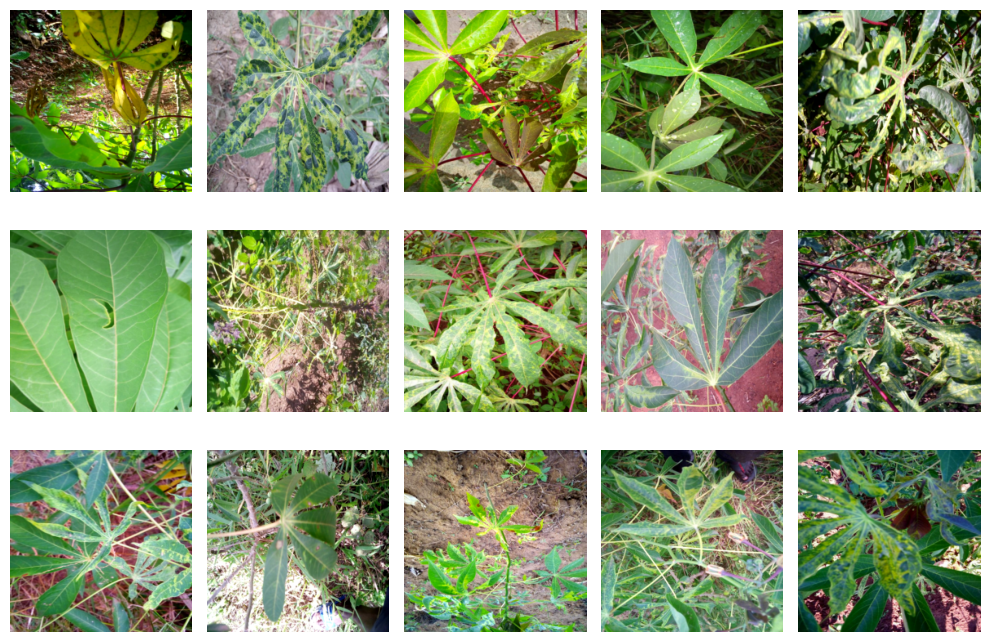

In [41]:
# Visualise a few training samples
batch = next(iter(train_loader))
images, labels = batch
images_np = images.numpy()   # (B, H, W, C) float32, samplewise-normalised

# Re-scale to [0,1] for display (approximate reverse of samplewise normalisation)
def show_img(ax, arr):
    arr = arr - arr.min()
    rng = arr.max()
    if rng > 0:
        arr /= rng
    ax.imshow(np.clip(arr, 0, 1))
    ax.axis('off')

fig, axes = plt.subplots(3, 5, figsize=(10, 7))
for img, ax in zip(images_np[:15], axes.flatten()):
    show_img(ax, img.copy())
plt.tight_layout()
plt.show()

# Building the Model

## 1. ViT B32 Model

In [42]:
if _HAS_KERAS_HUB:
    # Pre-trained ViT-B/32 backbone (ImageNet-21k weights)
    # Adjust the preset name to one listed in keras_hub.models.ViTBackbone.presets
    VIT_PRESET = "vit_base_patch32_224_imagenet21k"   # <-- change if needed
    try:
        vit_backbone = keras_hub.models.ViTBackbone.from_preset(
            VIT_PRESET,
            image_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        )
        print(f"Loaded pre-trained backbone: {VIT_PRESET}")
        _use_pretrained = True
    except Exception as exc:
        print(f"Could not load preset '{VIT_PRESET}': {exc}")
        print("Falling back to custom ViT (no pre-trained weights).")
        _use_pretrained = False
else:
    _use_pretrained = False

In [43]:
# ── Custom ViT used when keras_hub / preset is unavailable ──────────────────
# Architecture mirrors ViT-B/32: patch_size=32, projection_dim=768,
# 12 transformer layers, 12 attention heads.

if not _use_pretrained:

    class PatchEncoder(keras.layers.Layer):
        def __init__(self, num_patches, projection_dim, **kwargs):
            super().__init__(**kwargs)
            self.num_patches      = num_patches
            self.projection       = keras.layers.Dense(projection_dim)
            self.position_embedding = keras.layers.Embedding(
                input_dim=num_patches, output_dim=projection_dim
            )

        def call(self, patch):
            positions = keras.ops.arange(0, self.num_patches, step=1)
            return self.projection(patch) + self.position_embedding(positions)

    def _build_custom_vit(
        image_size=IMAGE_SIZE,
        patch_size=32,
        projection_dim=96,
        transformer_layers=8,
        num_heads=4,
        num_classes=NUM_CLASSES,
    ):
        num_patches = (image_size // patch_size) ** 2   # 7×7 = 49 for 224/32

        inputs  = keras.Input(shape=(image_size, image_size, 3))

        # Linear patch projection via non-overlapping Conv2D
        patches = keras.layers.Conv2D(
            filters=projection_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid",
            use_bias=False,
        )(inputs)
        patches = keras.layers.Reshape((num_patches, projection_dim))(patches)
        x       = PatchEncoder(num_patches, projection_dim)(patches)

        for _ in range(transformer_layers):
            x1  = keras.layers.LayerNormalization(epsilon=1e-6)(x)
            att = keras.layers.MultiHeadAttention(
                num_heads=num_heads,
                key_dim=projection_dim // num_heads,
                dropout=0.1,
            )(x1, x1)
            x2  = keras.layers.Add()([att, x])
            x3  = keras.layers.LayerNormalization(epsilon=1e-6)(x2)
            x3  = keras.layers.Dense(projection_dim * 4, activation='gelu')(x3)
            x3  = keras.layers.Dropout(0.1)(x3)
            x3  = keras.layers.Dense(projection_dim)(x3)
            x3  = keras.layers.Dropout(0.1)(x3)
            x   = keras.layers.Add()([x3, x2])

        x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
        x = keras.layers.GlobalAveragePooling1D()(x)  # (B, projection_dim)
        return x, inputs

    _backbone_outputs, _backbone_inputs = _build_custom_vit()
    print("Custom ViT backbone built (no pre-trained weights).")

Custom ViT backbone built (no pre-trained weights).


## 2. Fine-tuning the Model

In [44]:
if _use_pretrained:
    # ── keras_hub path ──────────────────────────────────────────────────────
    inputs  = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    features = vit_backbone(inputs)          # shape: (B, projection_dim)
    x       = keras.layers.Flatten()(features)
    x       = keras.layers.BatchNormalization()(x)
    x       = keras.layers.Dense(11, activation='gelu')(x)  # tfa.activations.gelu → 'gelu'
    x       = keras.layers.BatchNormalization()(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model   = keras.Model(inputs=inputs, outputs=outputs, name='vision_transformer')

else:
    # ── custom-backbone path ────────────────────────────────────────────────
    x       = keras.layers.Flatten()(_backbone_outputs)
    x       = keras.layers.BatchNormalization()(x)
    x       = keras.layers.Dense(11, activation='gelu')(x)
    x       = keras.layers.BatchNormalization()(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model   = keras.Model(inputs=_backbone_inputs, outputs=outputs, name='vision_transformer')

model.summary()

Model: "vision_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 96)  │    294,912 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 49, 96)    │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_3     │ (None, 49, 96)    │     14,016 │ reshape_3[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 96)    │        192 │ patch_encoder_3[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 96)    │     37,248 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_48 (Add)        │ (None, 49, 96)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 96)    │        192 │ add_48[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 49, 384)   │     37,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_73          │ (None, 49, 384)   │          0 │ dense_58[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 49, 96)    │     36,960 │ dropout_73[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_74          │ (None, 49, 96)    │          0 │ dense_59[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_49 (Add)        │ (None, 49, 96)    │          0 │ dropout_74[0][0], │
│                     │                   │            │ add_48[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 96)    │        192 │ add_49[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 96)    │     37,248 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_50 (Add)        │ (None, 49, 96)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_49[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 96)    │        192 │ add_50[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 49, 384)   │     37,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,205,395 (4.60 MB)

 Trainable params: 1,205,181 (4.60 MB)

 Non-trainable params: 214 (856.00 B)

# Training the Model

In [ ]:
learning_rate = 1e-4

# tfa.optimizers.RectifiedAdam  →  keras.optimizers.AdamW
# RectifiedAdam ≈ Adam with variance rectification; AdamW (weight-decay Adam)
# is the closest native Keras 3 equivalent with similar behaviour.
optimizer = keras.optimizers.AdamW(
    learning_rate=learning_rate,
    weight_decay=1e-4,
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.2),
    metrics=['accuracy'],
)

# ── Callbacks (same logic as original) ──────────────────────────────────────
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=2,
    verbose=1,
    min_delta=1e-4,
    min_lr=1e-6,
    mode='max',
)

earlystopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    min_delta=1e-4,
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1,
)

# .keras format is the recommended Keras 3 serialisation format
checkpointer = keras.callbacks.ModelCheckpoint(
    filepath='./model.keras',          # was './model.hdf5'
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max',
)

callbacks = [earlystopping, reduce_lr, checkpointer]

# ── Training ─────────────────────────────────────────────────────────────────
# Keras 3 accepts a PyTorch DataLoader directly in model.fit().
# No need to specify steps_per_epoch — Keras infers it from the DataLoader.
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=callbacks,
)

# Save in native Keras 3 format (was 'model.h5')
model.save('model.keras')

Epoch 1/7
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.3214 - loss: 1.7815
Epoch 1: val_accuracy improved from -inf to 0.11137, saving model to ./model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 33s 406ms/step - accuracy: 0.3220 - loss: 1.7798 - val_accuracy: 0.1114 - val_loss: 1.8115 - learning_rate: 1.0000e-04
Epoch 2/7
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3936 - loss: 1.6236
Epoch 2: val_accuracy improved from 0.11137 to 0.20405, saving model to ./model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.3936 - loss: 1.6235 - val_accuracy: 0.2040 - val_loss: 1.7917 - learning_rate: 1.0000e-04
Epoch 3/7
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4296 - loss: 1.5771
Epoch 3: val_accuracy did not improve from 0.20405
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.4295 - loss: 1.5771 - val_accuracy: 0.1589 - val_loss: 1.7037 - learning_rate: 1.0000e-04
Epoch 4/7
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4328 - loss: 1.5440
Ep

# Model Results

In [ ]:
all_preds = []
all_true  = []

for batch in val_loader:
    images, labels = batch
    # images: numpy (B, H, W, C), labels: numpy (B, num_classes) one-hot
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds,  axis=1))
    all_true.extend(np.argmax(labels.numpy(), axis=1))

predicted_classes = np.array(all_preds)
true_classes      = np.array(all_true)

print(classification_report(true_classes, predicted_classes))

confusionmatrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(16, 16))
sns.heatmap(confusionmatrix, cmap='Blues', annot=True, cbar=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## Generating test predictions

In [ ]:
test_preds = []
for images in test_loader:
    # test_loader yields images only (no labels)
    if isinstance(images, (list, tuple)):
        images = images[0]
    preds = model.predict(images, verbose=0)
    test_preds.extend(np.argmax(preds, axis=1))

DF_TEST['label'] = test_preds
DF_TEST['class'] = DF_TEST['label'].map(classes)
print(DF_TEST[['image_path', 'label', 'class']].head(10))